In [1]:
# Importing libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visualization style
sns.set(style="whitegrid")

# Loading dataset
# low_memory=False avoids dtype warnings due to mixed data types
df = pd.read_csv("IPL.csv", low_memory=False)

# View first rows
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [2]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Info about data types and missing values
df.info()

# Statistical summary
df.describe()

# Missing values check
df.isnull().sum()

Shape: (278205, 64)
Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
 

Unnamed: 0               0
match_id                 0
date                     0
match_type               0
event_name               0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
next_batter         264884
striker_out              0
Length: 64, dtype: int64

In [3]:
# Removing unnecessary column
# WHY: it's just an index column from dataset
df.drop(['Unnamed: 0'], axis=1, inplace=True)

# Convert date column to datetime
# WHY: helps in time-based analysis later
df['date'] = pd.to_datetime(df['date'])

# Handling missing values in wicket column
# WHY: NaN means no wicket happened
df['wicket_kind'].fillna('No Wicket', inplace=True)

C:\Users\au101\AppData\Local\Temp\ipykernel_16276\994635344.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wicket_kind'].fillna('No Wicket', inplace=True)


In [4]:
# Create a column for "is wicket"
# WHY: easier to count wickets numerically
df['is_wicket'] = df['wicket_kind'].apply(lambda x: 0 if x == 'No Wicket' else 1)

# Create total runs per ball (already exists but ensuring clarity)
df['total_runs'] = df['runs_total']

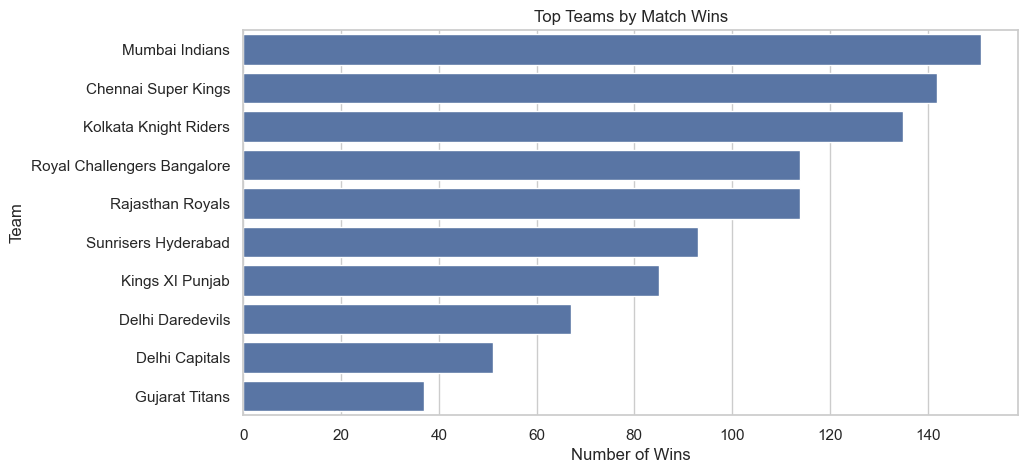

In [5]:
# Extract match winners (unique per match)
# WHY: avoid duplicate counting (many rows per match)
match_winners = df[['match_id', 'match_won_by']].drop_duplicates()

top_teams = match_winners['match_won_by'].value_counts().head(10)

plt.figure(figsize=(10,5))

# WHY: barplot helps compare categories clearly
sns.barplot(x=top_teams.values, y=top_teams.index)

plt.title("Top Teams by Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")

plt.show()

In [6]:
#Teams like MI / CSK (depending on dataset) dominate wins
#Strong franchises consistently perform better

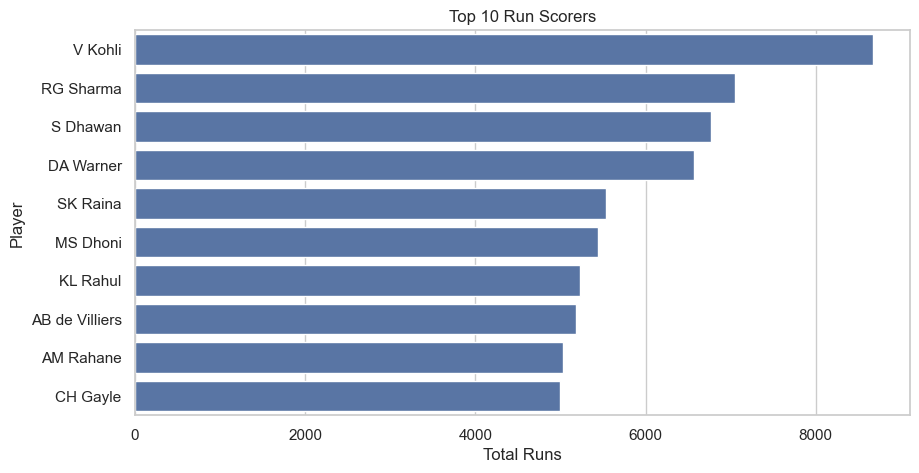

In [7]:
# Total runs scored by each batter
# WHY: aggregation converts ball data → player performance
top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_batters.values, y=top_batters.index)

plt.title("Top 10 Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.show()

In [8]:
#Top players are consistent performers across seasons
#High run scorers are key match influencers

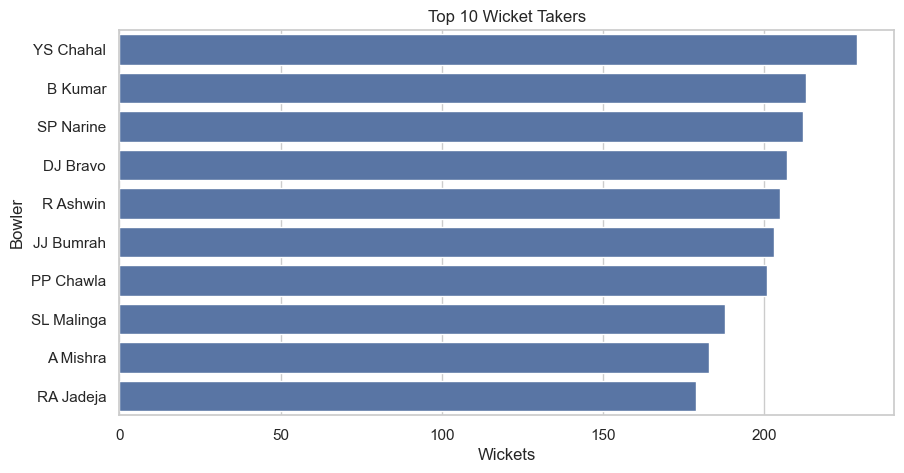

In [9]:
# Counting wickets per bowler
# WHY: using is_wicket simplifies counting
top_bowlers = df.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_bowlers.values, y=top_bowlers.index)

plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

In [10]:
#Top bowlers consistently take wickets across matches
#Wicket-taking ability is crucial for team success

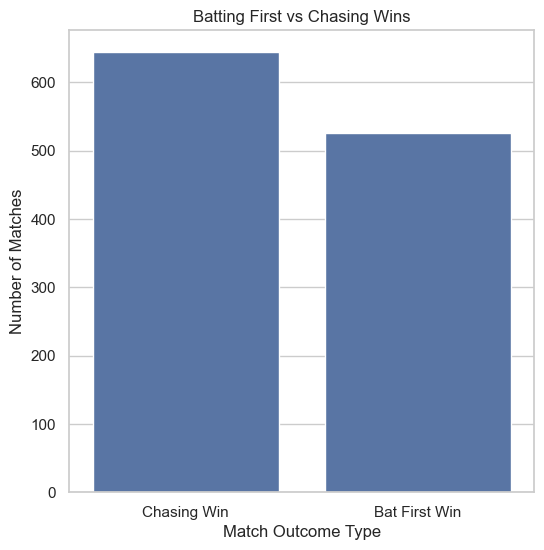

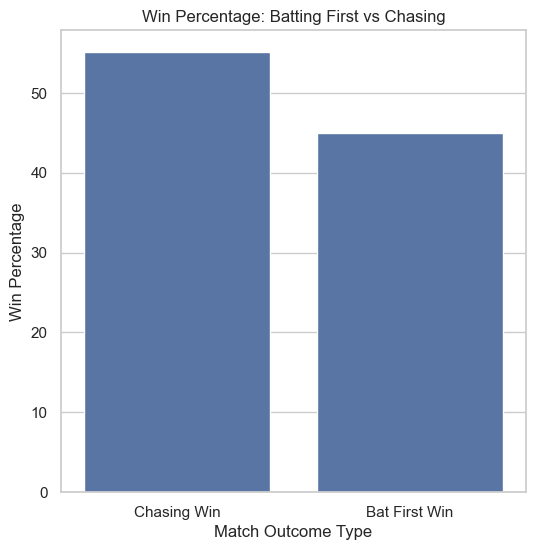

In [13]:

#Extract first innings team (batting first)
# WHY: first innings team sets the target, so used to define "batting first"
first_innings = df[df['innings'] == 1][['match_id', 'batting_team']].drop_duplicates()
first_innings.rename(columns={'batting_team': 'bat_first'}, inplace=True)


# Extract match winners (one row per match)
# WHY: avoids duplicate rows due to ball-by-ball data
winners = df[['match_id', 'match_won_by']].drop_duplicates()


# Merge datasets to get complete match info
# WHY: combine batting first team with match result
match_data = pd.merge(first_innings, winners, on='match_id')


# Create result column (Bat First Win vs Chasing Win)
# WHY: simplifies comparison into two clear categories
match_data['result'] = match_data.apply(
    lambda x: 'Bat First Win' if x['bat_first'] == x['match_won_by'] else 'Chasing Win',
    axis=1
)


# Plot count comparison
# WHY: count shows overall trend clearly
plt.figure(figsize=(6,6))

result_counts = match_data['result'].value_counts()

sns.barplot(x=result_counts.index, y=result_counts.values)

plt.title("Batting First vs Chasing Wins")
plt.xlabel("Match Outcome Type")
plt.ylabel("Number of Matches")

plt.show()


# Plot percentage comparison 
# WHY: percentage gives better understanding than raw numbers
plt.figure(figsize=(6,6))

result_percent = match_data['result'].value_counts(normalize=True) * 100

sns.barplot(x=result_percent.index, y=result_percent.values)

plt.title("Win Percentage: Batting First vs Chasing")
plt.xlabel("Match Outcome Type")
plt.ylabel("Win Percentage")

plt.show()

In [22]:
# Insight: Batting First vs Chasing

#- Chasing teams tend to win slightly more matches than teams batting first.
#- This indicates that knowing the target gives a strategic advantage.
#- However, the difference is not very large, meaning both strategies can succeed.

# Strategic Insight:
#Teams should base decisions on pitch conditions and team strength rather than blindly choosing to chase.

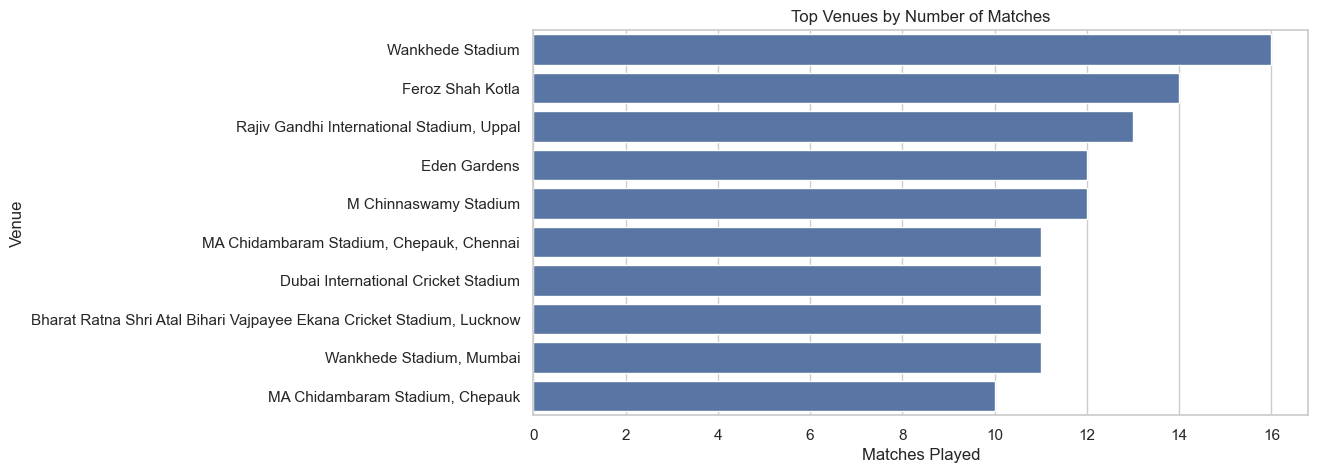

In [14]:
# Most successful teams at venues
venue_wins = df[['venue', 'match_won_by']].drop_duplicates()

top_venues = venue_wins['venue'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_venues.values, y=top_venues.index)

plt.title("Top Venues by Number of Matches")
plt.xlabel("Matches Played")
plt.ylabel("Venue")

plt.show()

In [15]:
#Some venues host more matches
#Teams familiar with venues may perform better

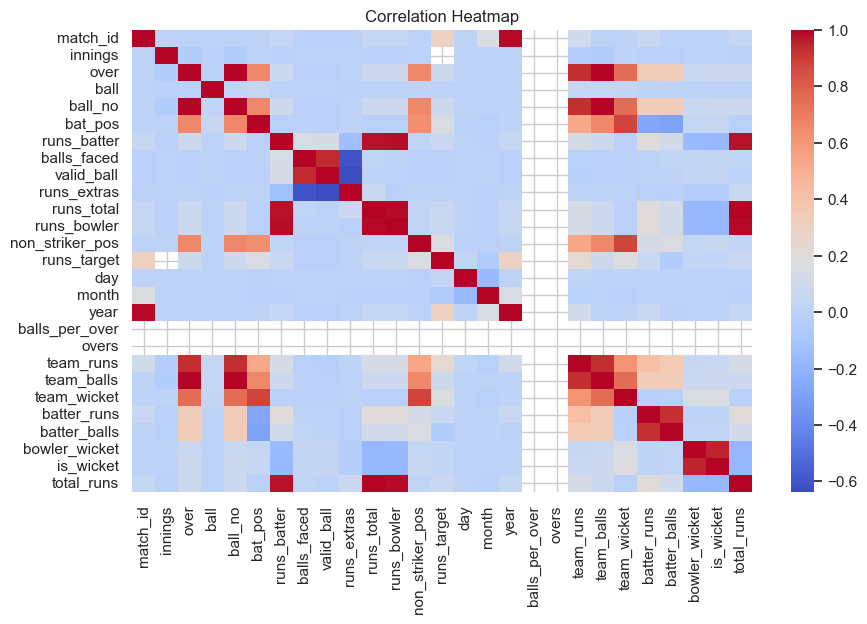

In [16]:
plt.figure(figsize=(10,6))

# Selecting numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# WHY: helps find relationships between variables
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

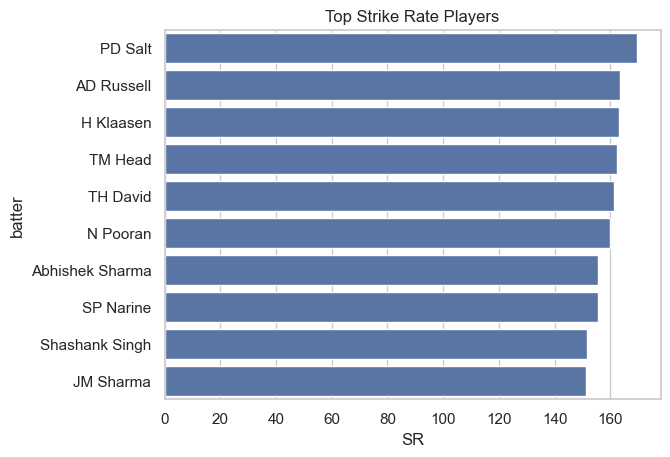

In [19]:
# WHY: measures scoring efficiency, not just total runs
strike_rate = df.groupby('batter').agg({
    'runs_batter': 'sum',
    'ball': 'count'
})

strike_rate['SR'] = (strike_rate['runs_batter'] / strike_rate['ball']) * 100

top_sr = strike_rate[strike_rate['ball'] > 500].sort_values(by='SR', ascending=False).head(10)

sns.barplot(x=top_sr['SR'], y=top_sr.index)
plt.title("Top Strike Rate Players")
plt.show()

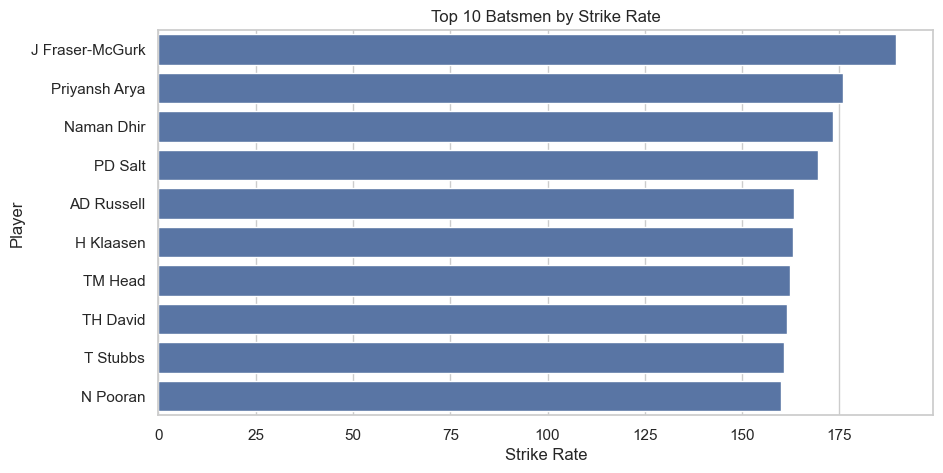

In [21]:
# Strike Rate Analysis

# WHY: shows efficiency, not just total runs
batsman_stats = df.groupby('batter').agg({
    'runs_batter': 'sum',
    'ball': 'count'
})

batsman_stats['strike_rate'] = (batsman_stats['runs_batter'] / batsman_stats['ball']) * 100

top_sr = batsman_stats[batsman_stats['ball'] > 200].sort_values(by='strike_rate', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sr['strike_rate'], y=top_sr.index)

plt.title("Top 10 Batsmen by Strike Rate")
plt.xlabel("Strike Rate")
plt.ylabel("Player")

plt.show()

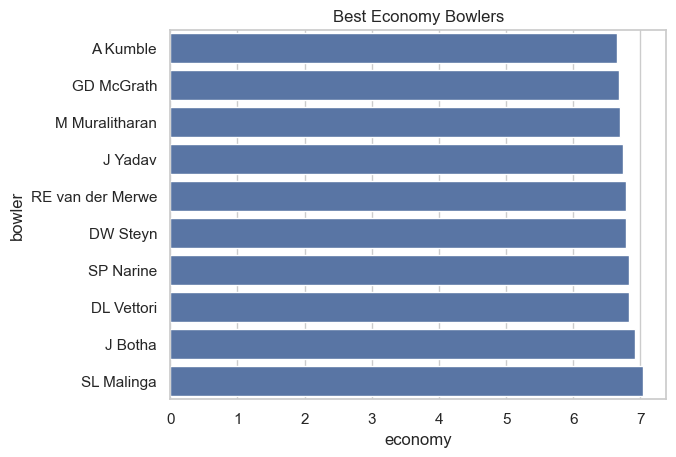

In [24]:
# Economy Rate
bowler_stats = df.groupby('bowler').agg({
    'runs_total': 'sum',
    'ball': 'count'
})

bowler_stats['overs'] = bowler_stats['ball'] / 6
bowler_stats['economy'] = bowler_stats['runs_total'] / bowler_stats['overs']

top_economy = bowler_stats[bowler_stats['overs'] > 50].sort_values(by='economy').head(10)

sns.barplot(x=top_economy['economy'], y=top_economy.index)
plt.title("Best Economy Bowlers")
plt.show()

In [17]:
#Insights

#- Certain teams dominate IPL across seasons
#- Top batters and bowlers consistently perform well
#- Match outcome depends on multiple factors
#- Toss and strategy (bat/chase) influence results
#- Venue plays a role in match dynamics

In [ ]:
### Insight: Batting First vs Chasing

#- Chasing teams win slightly more matches than teams batting first.
#- This indicates that having a clear target provides a strategic advantage.
#- However, the difference is not very large, meaning both strategies are viable.

# Key Takeaway:
#Match outcome is influenced by multiple factors like pitch, team strength, and conditions — not just batting order.